In [1]:
install.packages("KFAS")
install.packages("gridExtra")

library(KFAS)
library(ggplot2)
library(gridExtra)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Please cite KFAS in publications by using: 

  Jouni Helske (2017). KFAS: Exponential Family State Space Models in R. Journal of Statistical Software, 78(10), 1-39. doi:10.18637/jss.v078.i10.



In [2]:
dataset = Nile
dataset

A Time Series:
  [1] 1120 1160  963 1210 1160 1160  813 1230 1370 1140  995  935 1110  994 1020
 [16]  960 1180  799  958 1140 1100 1210 1150 1250 1260 1220 1030 1100  774  840
 [31]  874  694  940  833  701  916  692 1020 1050  969  831  726  456  824  702
 [46] 1120 1100  832  764  821  768  845  864  862  698  845  744  796 1040  759
 [61]  781  865  845  944  984  897  822 1010  771  676  649  846  812  742  801
 [76] 1040  860  874  848  890  744  749  838 1050  918  986  797  923  975  815
 [91] 1020  906  901 1170  912  746  919  718  714  740

In [3]:
summary(dataset)
str(dataset)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  456.0   798.5   893.5   919.4  1032.5  1370.0 

 Time-Series [1:100] from 1871 to 1970: 1120 1160 963 1210 1160 1160 813 1230 1370 1140 ...


In [4]:
head(dataset)

[1] 1120 1160  963 1210 1160 1160

In [5]:
time(dataset)

A Time Series:
  [1] 1871 1872 1873 1874 1875 1876 1877 1878 1879 1880 1881 1882 1883 1884 1885
 [16] 1886 1887 1888 1889 1890 1891 1892 1893 1894 1895 1896 1897 1898 1899 1900
 [31] 1901 1902 1903 1904 1905 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915
 [46] 1916 1917 1918 1919 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930
 [61] 1931 1932 1933 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945
 [76] 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960
 [91] 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970

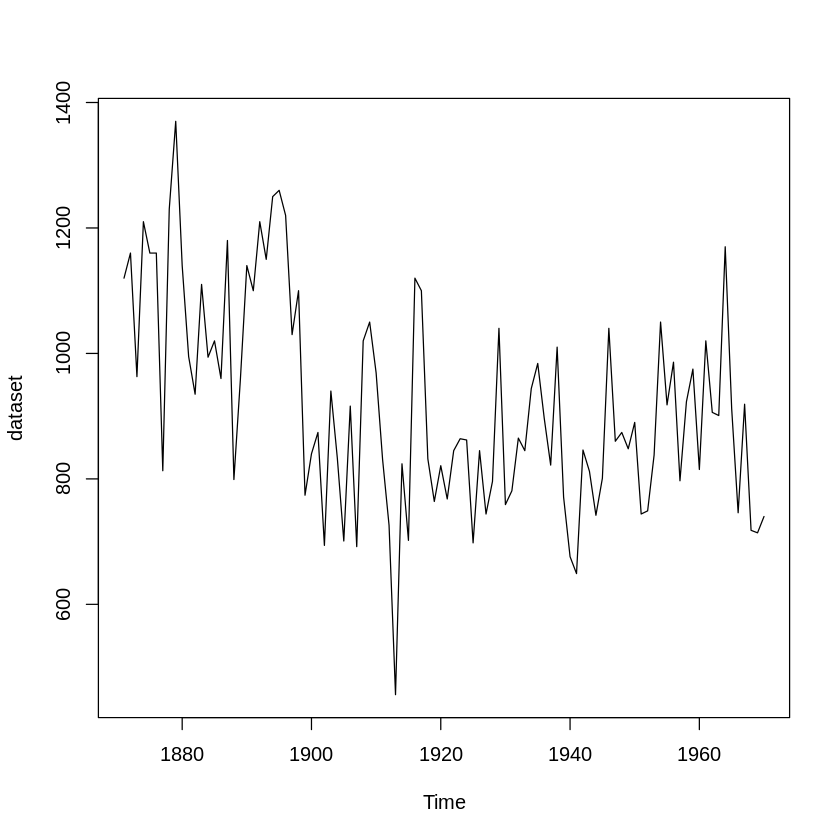

In [6]:
plot(dataset)

In [7]:
train = window(dataset, 1871, 1950)
test = window(dataset, 1951, 1970)

# **ローカルレベルモデル**

In [8]:
#モデルの構造決定　H = NAは観測誤差の分散について未設定ということ　degree = 1は１次トレンド　Q = NAはシステム誤差の分散が未設定ということ
build_model = SSModel(H = NA, train ~ SSMtrend(degree = 1, Q = NA))

#パラメータ推定　inits = c(1,1)は2つのパラメータの初期値を1に設定している　NAの部分を推定する
fit_kfas = fitSSM(build_model, inits = c(1,1))

In [9]:
#パラメータの推定結果
fit_kfas$model$Q
fit_kfas$model$H

, , 1

         [,1]
[1,] 1641.877

, , 1

         [,1]
[1,] 15734.23

,time,y,y_pred
,<dbl>,<dbl>,<dbl>
1,1871,1120,1120.000
2,1872,1160,1140.992
3,1873,963,1072.255
4,1874,1210,1117.586
5,1875,1160,1130.412
6,1876,1160,1138.967


Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.
Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


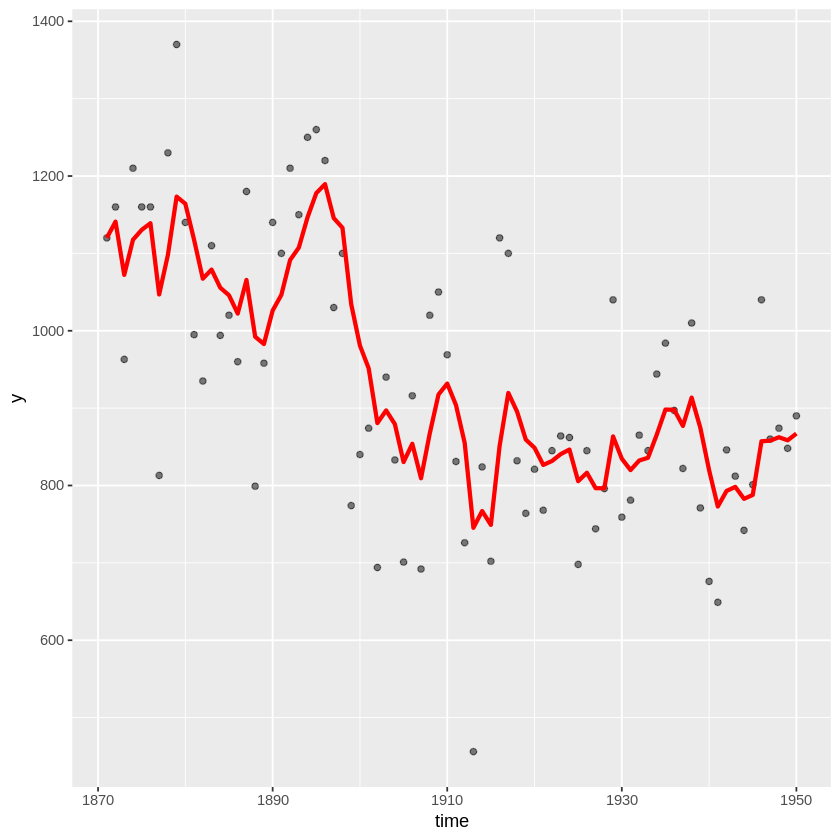

In [10]:
#フィルタリング推定量の評価

#フィルタリング　filtering = c("state", "mean")とsmoothing = c("state", "mean")はどちらも状態推定値と平均値を求めるように指定している
result_kfas = KFS(fit_kfas$model, filtering = c("state", "mean"), smoothing = c("state", "mean"))

df_filt = data.frame(time = time(train), y = train, y_pred = result_kfas$a[-1])
head(df_filt)

ggplot(data=df_filt, aes(x=time, y=y))+
  geom_point(alpha=0.5)+
  geom_line(aes(y=y_pred),linewidth=1.2, col = 'red')

In [11]:
#各値は1期先の状態（最初を削ることで各期の推定値を見ていることになる）
result_kfas$a

level
0.0000
1120.0000
1140.9918
1072.2547
1117.5865
1130.4116
1138.9666
1046.9221
1097.9782
1173.3426


,time,y,y_pred
,<dbl>,<dbl>,<dbl>
1,1871,1120,1120.000
2,1872,1160,1140.992
3,1873,963,1072.255
4,1874,1210,1117.586
5,1875,1160,1130.412
6,1876,1160,1138.967


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.
Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


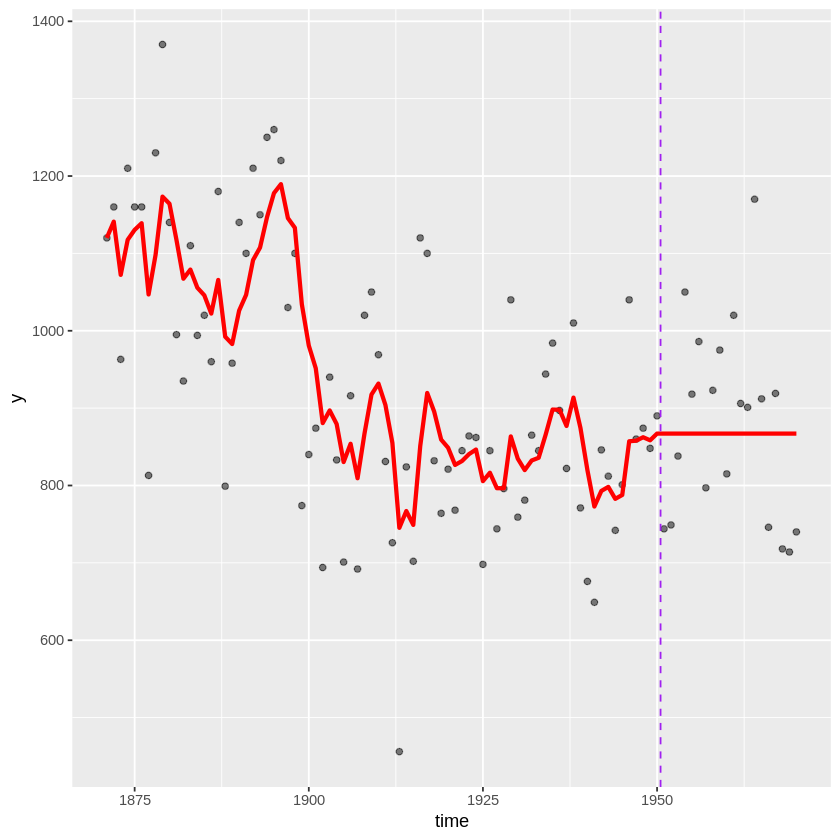

In [12]:

#予測の評価

#20年先の結果を予測
pred = predict(fit_kfas$model, interval = "prediction", n.ahead = 20)

df_pred = data.frame(time = time(dataset), y = dataset, y_pred = c(result_kfas$a[-1], pred[,1]))
head(df_pred)

ggplot(data=df_pred, aes(x=time, y=y))+
  geom_point(alpha=0.5)+
  geom_line(aes(y=y_pred),size=1.2, col = 'red') +
  geom_vline(xintercept= 1950.5, col = 'purple', linetype='dashed')

,time,fit,lwr,upr,y
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1871,1111.958,983.0228,1240.894,1120
2,1872,1111.119,995.7522,1226.486,1160
3,1873,1105.179,997.6274,1212.731,963
4,1874,1114.076,1010.8682,1217.283,1210
5,1875,1112.963,1012.1133,1213.812,1160
6,1876,1106.941,1007.3535,1206.529,1160


Don't know how to automatically pick scale for object of type <ts>. Defaulting
to continuous.


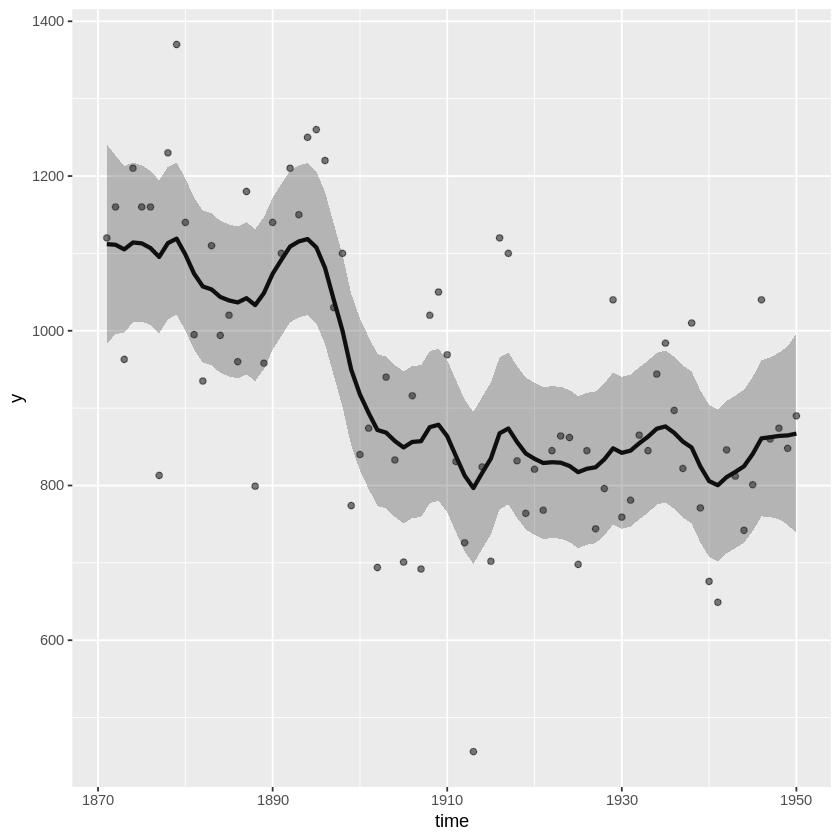

In [13]:
#スムージングの評価
#interval = "confidence"は予測結果に信頼区間を含めることを指定する　level = 0.95は95%信頼区間を設定している
smooth_kfas = predict(fit_kfas$model, interval = "confidence", level = 0.95)

df_smooth = data.frame(time = time(train), smooth_kfas, y = as.numeric(train))
head(df_smooth)

ggplot(data = df_smooth,aes(x=time,y=y)) +
  geom_point(alpha=0.5) +
  geom_line(aes(y=fit),size=1.2) +
  geom_ribbon(aes(ymin=lwr,ymax=upr),alpha=0.3)

**2つの説明変数を持つモデルの実装(切片と回帰係数は状態方程式から算出)**

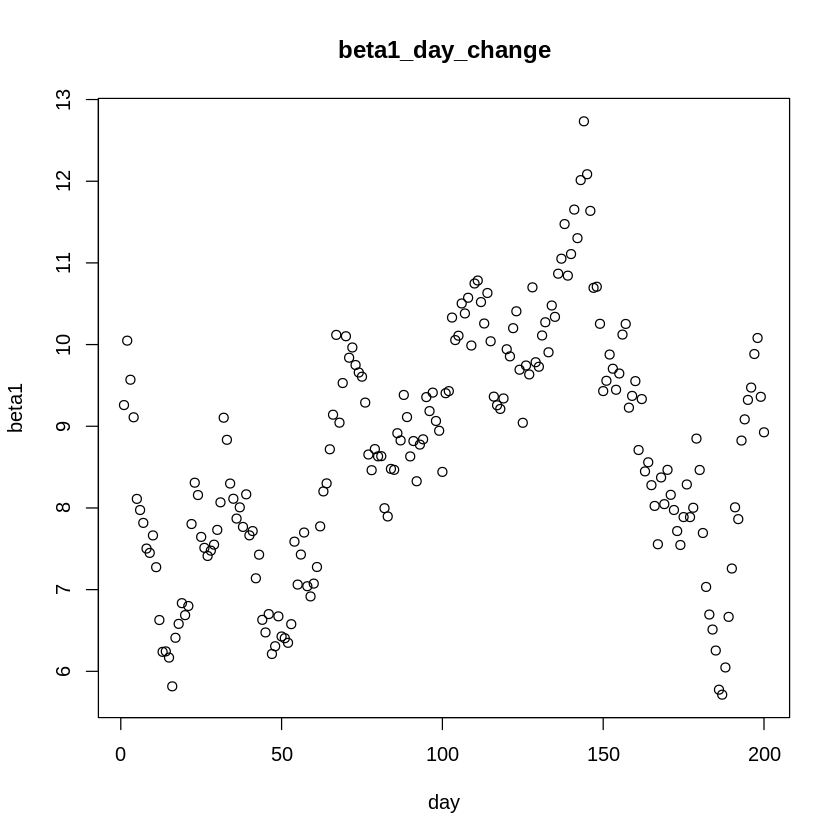

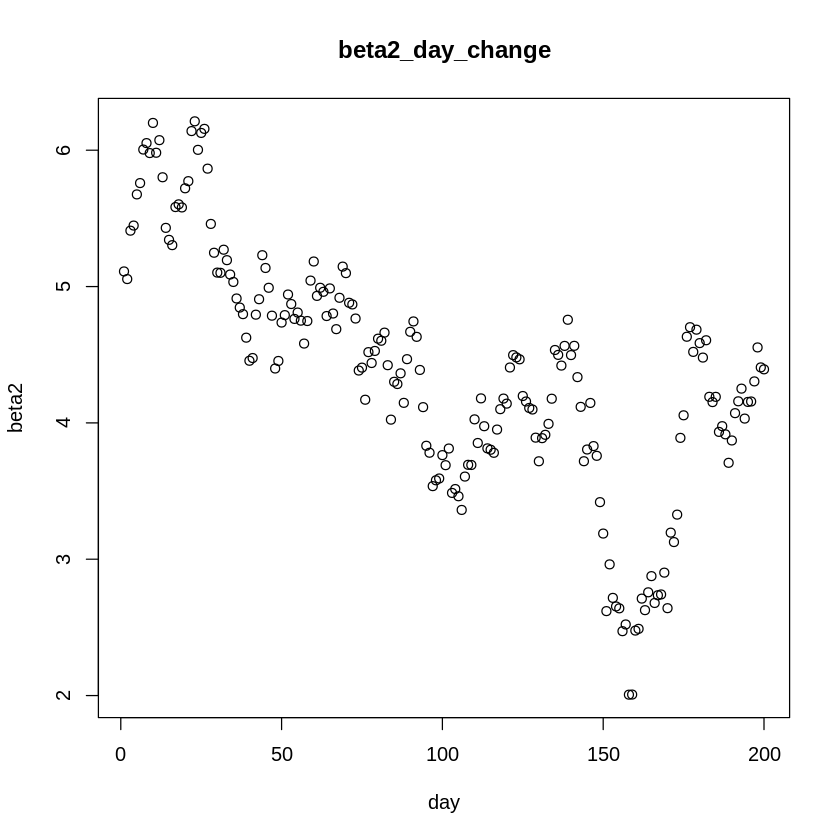

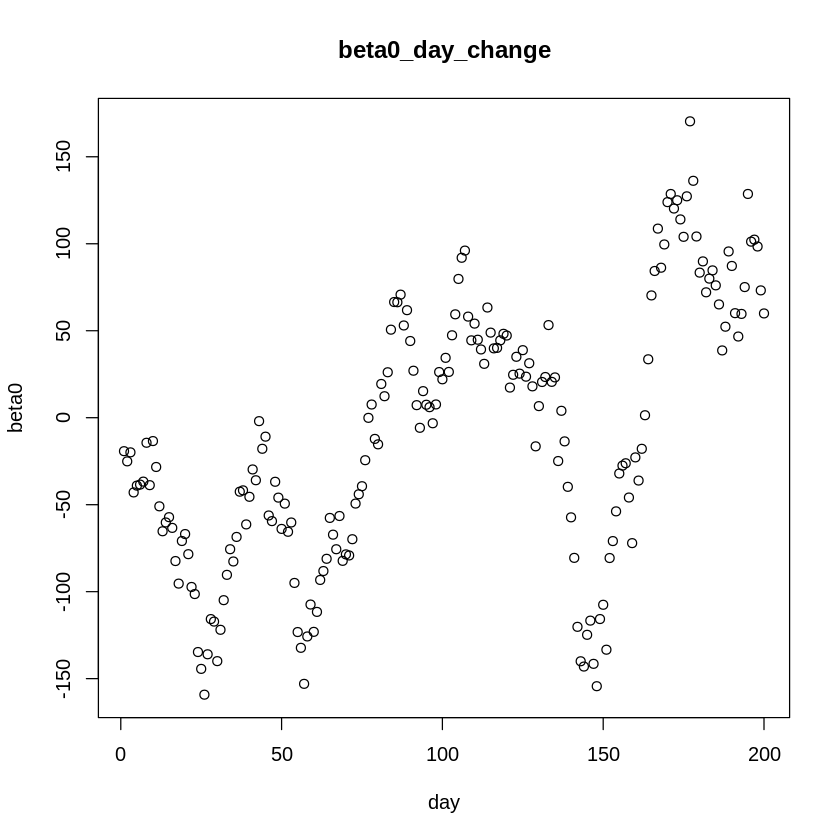

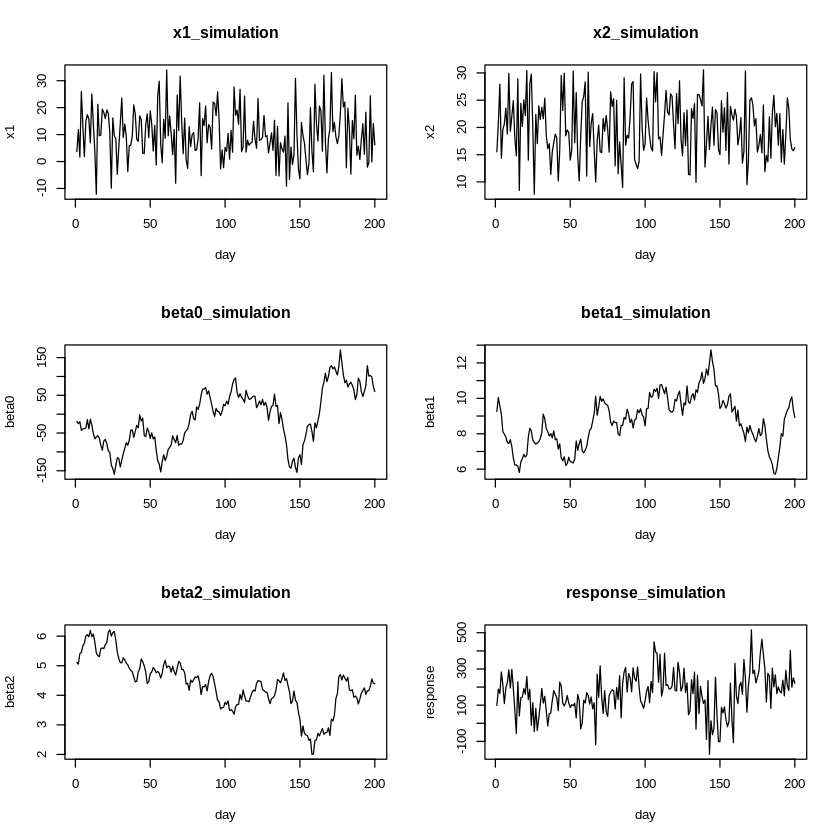

In [14]:
#架空データの作成
N = 200
observationErrorSD = 20
processErrorSD = 20
coefErrorSD1 = 0.5
coefErrorSD2 = 0.2

set.seed(1)
x1 = rnorm(n=N, mean=10, sd=10)

set.seed(2)
x2 = rnorm(n=N, mean=20, sd=5)

#回帰係数1,2のシミュレーション
set.seed(12)
beta1 = cumsum(rnorm(n=N, mean=0, sd=coefErrorSD1)) + 10
set.seed(13)
beta2 = cumsum(rnorm(n=N, mean=0, sd=coefErrorSD2)) + 5
plot(beta1, main="beta1_day_change", xlab="day")
plot(beta2, main="beta2_day_change", xlab="day")

#切片のシミュレーション
set.seed(3)
beta0 = cumsum(rnorm(n=N, mean=0, sd=processErrorSD))
plot(beta0, main="beta0_day_change", xlab="day")

#resposeのシミュレーション
set.seed(4)
response = beta0 + beta1*x1 + beta2*x2 + rnorm(n=N, mean=0, sd=observationErrorSD)

par(mfrow=c(3,2))
plot(x1, main="x1_simulation", xlab="day",type="l")
plot(x2, main="x2_simulation", xlab="day",type="l")
plot(beta0, main="beta0_simulation", xlab="day",type="l")
plot(beta1, main="beta1_simulation", xlab="day",type="l")
plot(beta2, main="beta2_simulation", xlab="day",type="l")
plot(response, main="response_simulation", xlab="day",type="l")
par(mfrow=c(1,1))

In [15]:
#モデルの構造決定　 ~ x1 + x2で説明変数を追加　Q = diag(rep(NA, 2))でそれぞれの説明変数におけるシステム誤差の分散が未設定になる
build = SSModel(H = NA, response ~
SSMtrend(degree = 1, Q = NA) +
SSMregression( ~ x1 + x2, Q = diag(rep(NA, 2))))

#パラメータの推定　inits = c(1,1,1,1)で回帰係数1、回帰係数2、切片、観測誤差の4つの未知数について分散の初期値をいずれも1に設定している
fit_reg = fitSSM(build, inits = c(1,1,1,1))

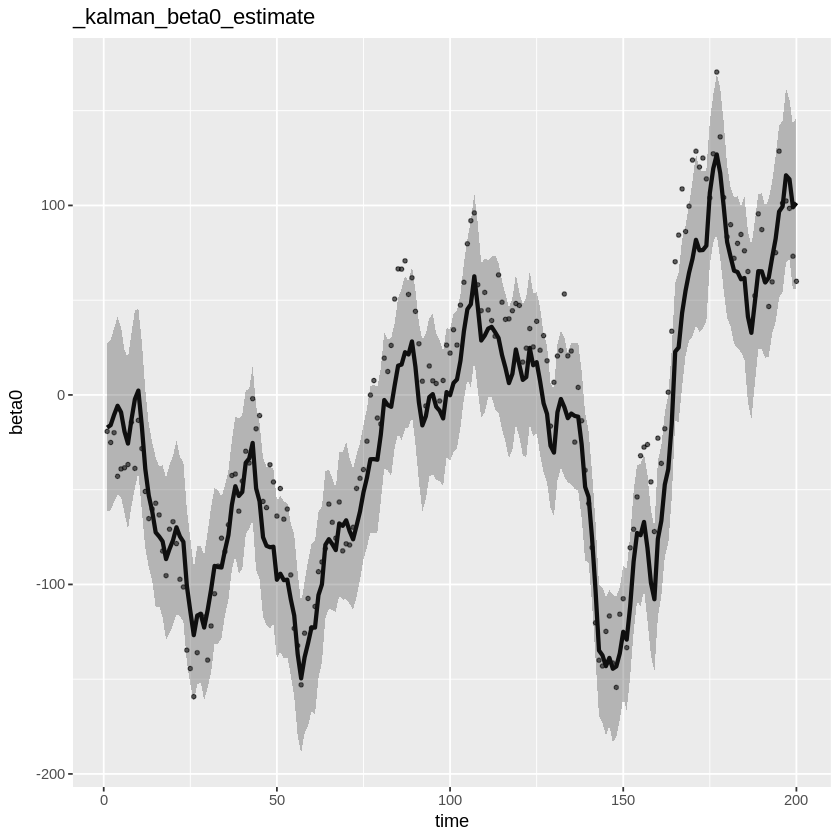

In [16]:
#切片の推定結果
pred_beta0 = predict(fit_reg$model, states = "level", interval = "confidence", level = 0.95)

beta0_df = cbind(
data.frame(time = 1:200, beta0 = beta0),
as.data.frame(pred_beta0)
)

g1 = ggplot(data = beta0_df, aes(x = time, y = beta0)) +
labs(title="_kalman_beta0_estimate") +
geom_point(alpha = 0.6, size = 0.9) +
geom_line(aes(y = fit), size = 1.2) +
geom_ribbon(aes(ymin = lwr, ymax = upr), alpha = 0.3)

g1

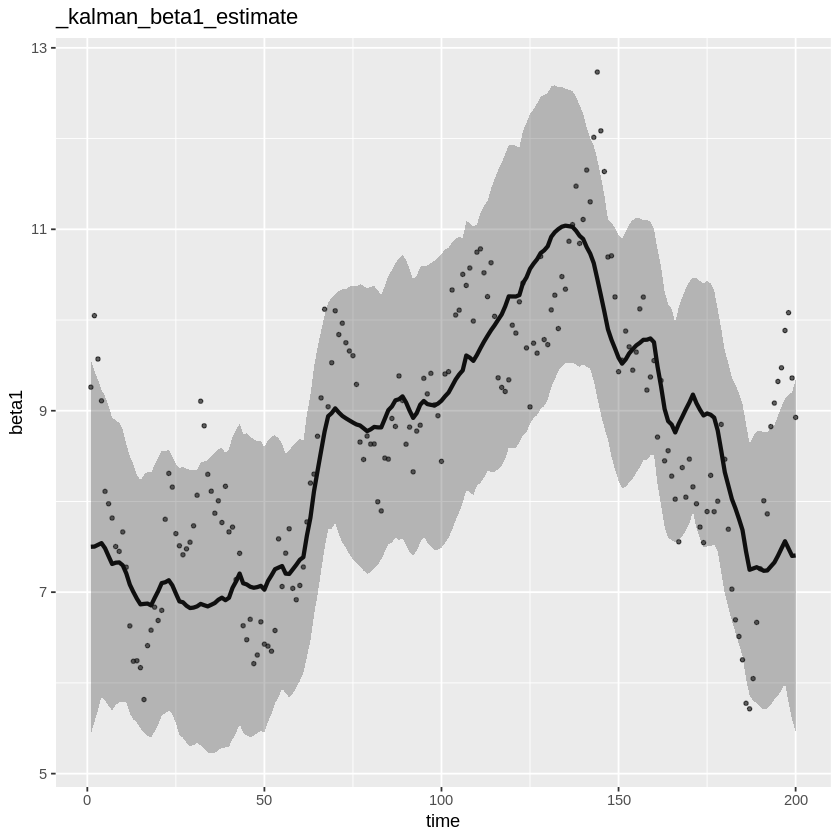

In [17]:
#回帰係数1の推定結果
pred_beta1 = predict(fit_reg$model, states = 1, interval = "confidence", level = 0.95)

#pred_beta1には説明変数と回帰係数の積が格納されているので説明変数で割ることで回帰係数のみにする
pred_beta1_adj = data.frame(
"fit" = t(apply(pred_beta1/x1, 1, sort))[, 2],
"lwr" = t(apply(pred_beta1/x1, 1, sort))[, 1],
"upr" = t(apply(pred_beta1/x1, 1, sort))[, 3]
)

beta1_df = cbind(
data.frame(time = 1:200, beta1 = beta1),
as.data.frame(pred_beta1_adj)
)

g2 = ggplot(data = beta1_df, aes(x = time, y = beta1)) +
labs(title="_kalman_beta1_estimate") +
geom_point(alpha = 0.6, size = 0.9) +
geom_line(aes(y = fit), size = 1.2) +
geom_ribbon(aes(ymin = lwr, ymax = upr), alpha = 0.3)

g2

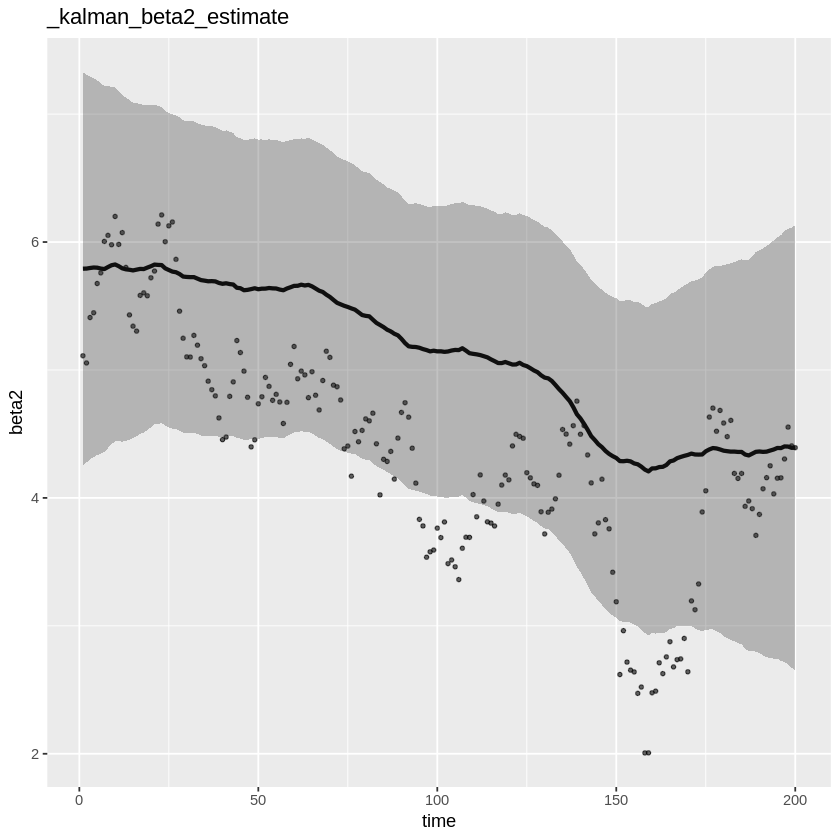

In [18]:
#回帰係数2の推定結果
pred_beta2 = predict(fit_reg$model, states = 2, interval = "confidence", level = 0.95)

#pred_beta2には説明変数と回帰係数の積が格納されているので説明変数で割ることで回帰係数のみにする
pred_beta2_adj = data.frame(
"fit" = t(apply(pred_beta2/x2, 1, sort))[, 2],
"lwr" = t(apply(pred_beta2/x2, 1, sort))[, 1],
"upr" = t(apply(pred_beta2/x2, 1, sort))[, 3]
)

beta2_df = cbind(
data.frame(time = 1:200, beta2 = beta2),
as.data.frame(pred_beta2_adj)
)

g2 = ggplot(data = beta2_df, aes(x = time, y = beta2)) +
labs(title="_kalman_beta2_estimate") +
geom_point(alpha = 0.6, size = 0.9) +
geom_line(aes(y = fit), size = 1.2) +
geom_ribbon(aes(ymin = lwr, ymax = upr), alpha = 0.3)

g2

**線形非ガウス状態空間モデル**

In [19]:
#観測値がu=1のポアソン分布に従う　2次のトレンド成分 + 季節成分
pois_model = SSModel(train ~ SSMtrend(2, Q = list(0, NA)) +
SSMseasonal(12, Q = NA), distribution = "poisson", u = 1)

#疑似ニュートン法による最適化
fit_model = fitSSM(pois_model, c(1,1), nsim = 1000, method = "BFGS")

#各時点の状態の推定値kfs_pois$alphahat 各時点の信号に基づく観測値の期待値の推定値kfs_pois$muhat　などが格納されている
kfs_pois = KFS(fit_model$model, filtering = c("state","mean"), smoothing = c("state","mean"), nsim = 1000)

In [20]:
kfs_pois$a

,level,slope,sea_dummy1,sea_dummy2,sea_dummy3,sea_dummy4,sea_dummy5,sea_dummy6,sea_dummy7,sea_dummy8,sea_dummy9,sea_dummy10,sea_dummy11
1871,0.000000,0.000000e+00,0.00000000,0.000000000,0.0000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000
1872,3.510329,6.233701e-06,-3.51025094,3.510328987,0.0000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000
1873,5.138570,5.427234e-01,-0.54280589,2.459963035,2.9675838203,-0.542740189,-0.542740189,-0.542740189,-0.542740189,-0.542740189,-0.542740189,-0.542740189,-0.542740189
1874,8.258125,1.350980e+00,-0.47564171,-0.037484554,1.4999311682,2.816011408,-0.475363555,-0.475363555,-0.475363555,-0.475363555,-0.475363555,-0.475363555,-0.475363555
1875,9.029975,1.197861e+00,-0.48807288,-0.734070359,0.2356834557,1.620149649,2.783217408,-0.488120869,-0.488120869,-0.488120869,-0.488120869,-0.488120869,-0.488120869
1876,9.196636,9.625442e-01,-0.50783659,-1.178550107,-0.1738383729,0.560430736,1.709386746,2.636901206,-0.507752744,-0.507752744,-0.507752744,-0.507752744,-0.507752744
1877,9.190949,7.684718e-01,-0.52392753,-1.366876615,-0.5987863943,0.211665958,0.751693946,1.706407355,2.439589086,-0.523945146,-0.523945146,-0.523945146,-0.523945146
1878,8.938989,5.862400e-01,-0.53924763,-1.652645916,-0.7107074596,-0.124751798,0.503478941,0.861383634,1.634001889,2.184988813,-0.539119673,-0.539119673,-0.539119673
1879,8.932111,4.909187e-01,-0.54711034,-1.326924643,-1.2500336221,-0.403300267,0.087458011,0.620462107,0.883203066,1.560681485,2.016583200,-0.547051327,-0.547051327
1880,8.940293,4.206661e-01,-0.55266754,-1.297402998,-0.9848154477,-0.978302114,-0.201863555,0.218608533,0.681284232,0.873723232,1.480895595,1.866406597,-0.552911504
